In [2]:
import geopandas as gpd


In [4]:

gdf = gpd.read_file("hospitales.geojson")

print(gdf.head())

                  id                @id addr:city addr:housenumber  \
0  relation/11632168  relation/11632168      None             None   
1       way/27804337       way/27804337    México              116   
2     node/319436637     node/319436637      None             None   
3     node/739035810     node/739035810      None             None   
4      way/883666969      way/883666969      None    120 y Canario   

  addr:postcode             addr:street   amenity building check_date  \
0          None                    None  hospital     None        NaT   
1         01120                 Sur 136  hospital     None        NaT   
2          None                    None  hospital     None        NaT   
3          None                    None  hospital     None        NaT   
4         01140  General Felipe Ángeles  hospital     None        NaT   

       created_by  ...                                           operator  \
0            None  ...               Instituto Mexicano del Seg

In [6]:
gdf.columns

Index(['id', '@id', 'addr:city', 'addr:housenumber', 'addr:postcode',
       'addr:street', 'amenity', 'building', 'check_date', 'created_by',
       'description', 'emergency', 'healthcare', 'healthcare:speciality',
       'internet_access', 'name', 'note', 'opening_hours', 'operator',
       'operator:short', 'operator:type', 'operator:wikidata', 'phone', 'type',
       'website', 'wheelchair', '@geometry', 'geometry'],
      dtype='object')

In [8]:
hospitales = gdf[[
    "id",
    "name",
    "healthcare:speciality",
    "emergency",
    "operator:short",
    "geometry"
]].copy()


hospitales["lat"] = hospitales.geometry.y
hospitales["lon"] = hospitales.geometry.x


hospitales = hospitales.rename(columns={
    "id": "id_osm",
    "name": "nombre",
    "healthcare:speciality": "especialidades_osm",
    "operator:short": "institucion",
    "emergency": "emergencias"
})

hospitales = hospitales[[
    "id_osm",
    "nombre",
    "lat",
    "lon",
    "especialidades_osm",
    "emergencias",
    "institucion",
]]

hospitales

,id_osm,nombre,lat,lon,especialidades_osm,emergencias,institucion
0,relation/11632168,Complejo de hospitales IMSS,19.336820,-99.200272,None,yes,IMSS
1,way/27804337,Centro Médico ABC,19.400212,-99.203998,general;paediatrics;gynaecology;emergency;surg...,yes,None
2,node/319436637,Hospital San Angel Inn,19.340353,-99.199841,None,None,None
3,node/739035810,Clínica Hospital 8 IMSS,19.336612,-99.200969,None,None,IMSS
4,way/883666969,Hospital General Dr. Fernando Quiroz Gutiérrez...,19.394387,-99.194223,None,None,ISSSTE
5,way/986068924,Centro de Atención a la Salud T-III Jalalpa,19.371641,-99.238921,None,None,None
6,way/1364990384,None,19.360337,-99.176509,None,None,None
7,way/1365216619,"Hospital Regional ""Lic. Adolfo López Mateos""",19.358356,-99.172605,None,yes,ISSSTE
8,way/1365266055,"Hospital Regional ""Lic. Adolfo López Mateos""",19.358713,-99.173006,None,None,ISSSTE
9,node/2324519237,Hospital General Enrique Cabrera,19.361589,-99.224313,None,yes,None


In [10]:
#Cambios artificiales hechos con el fin de probar la correcta ejecución del proyecto 
# NO SON DATOS REALES: FUERON ALTERACIONES HECHAS AL JSON ORIGINAL

hospitales["emergencias"] = hospitales["emergencias"].fillna("yes")

hospitales.loc[0, "especialidades_osm"] = "general;trauma;urgencias"
hospitales.loc[1, "especialidades_osm"] = "general;cardiologia;pediatria;ginecologia;emergencia;cirugia;cardiologia;oncologia;cardiologia;radiologia;intensivo;interno" 
#en tupla 1 el valor original era:general;paediatrics;gynaecology;emergency;surgery;cardiology;oncology;radiology;intensive;internal
hospitales.loc[2, "especialidades_osm"] = "pediatria;urgencias;cirugia"
hospitales.loc[3, "especialidades_osm"] = "general;trauma;neurologia;urgencias"
hospitales.loc[4, "especialidades_osm"] = "general;cardiologia;radiologia;intensivo"
hospitales.loc[5, "especialidades_osm"] = "pediatria;ginecologia;urgencias"
hospitales.loc[6, "especialidades_osm"] = "general;cirugia;oncologia;radiologia"
hospitales.loc[7, "especialidades_osm"] = "trauma;ortopedia;urgencias;cirugia"
hospitales.loc[8, "especialidades_osm"] = "general;neurologia;cardiologia;intensivo"
hospitales.loc[9, "especialidades_osm"] = "pediatria;general;urgencias;interno"
hospitales.loc[10, "especialidades_osm"] = "general;ginecologia;maternidad;cirugia"
hospitales.loc[11, "especialidades_osm"] = "trauma;urgencias;radiologia;intensivo"
hospitales.loc[12, "especialidades_osm"] = "general;cardiologia;oncologia;neurologia"


In [12]:
hospitales

,id_osm,nombre,lat,lon,especialidades_osm,emergencias,institucion
0,relation/11632168,Complejo de hospitales IMSS,19.336820,-99.200272,general;trauma;urgencias,yes,IMSS
1,way/27804337,Centro Médico ABC,19.400212,-99.203998,general;cardiologia;pediatria;ginecologia;emer...,yes,None
2,node/319436637,Hospital San Angel Inn,19.340353,-99.199841,pediatria;urgencias;cirugia,yes,None
3,node/739035810,Clínica Hospital 8 IMSS,19.336612,-99.200969,general;trauma;neurologia;urgencias,yes,IMSS
4,way/883666969,Hospital General Dr. Fernando Quiroz Gutiérrez...,19.394387,-99.194223,general;cardiologia;radiologia;intensivo,yes,ISSSTE
5,way/986068924,Centro de Atención a la Salud T-III Jalalpa,19.371641,-99.238921,pediatria;ginecologia;urgencias,yes,None
6,way/1364990384,None,19.360337,-99.176509,general;cirugia;oncologia;radiologia,yes,None
7,way/1365216619,"Hospital Regional ""Lic. Adolfo López Mateos""",19.358356,-99.172605,trauma;ortopedia;urgencias;cirugia,yes,ISSSTE
8,way/1365266055,"Hospital Regional ""Lic. Adolfo López Mateos""",19.358713,-99.173006,general;neurologia;cardiologia;intensivo,yes,ISSSTE
9,node/2324519237,Hospital General Enrique Cabrera,19.361589,-99.224313,pediatria;general;urgencias;interno,yes,None


In [14]:
hospitales.to_csv("hospitales_limpio.csv", index=False)

In [16]:
hospitales.to_excel("hospitales_limpio.xlsx", index=False)

In [18]:
import random
import pandas as pd

filas = []

for i, row in hospitales.iterrows():

    especialidades = row["especialidades_osm"].split(";")

    for esp in especialidades:

        filas.append({
            "id_hospital": row["id_osm"],
            "hospital": row["nombre"],
            "especialidad": esp.strip(),

            # Datos simulados
            "camas_totales": random.randint(1, 15),

            "camas_ocupadas": random.randint(0, 10)
        })

capacidades = pd.DataFrame(filas)

capacidades

,id_hospital,hospital,especialidad,camas_totales,camas_ocupadas
0,relation/11632168,Complejo de hospitales IMSS,general,1,5
1,relation/11632168,Complejo de hospitales IMSS,trauma,10,4
2,relation/11632168,Complejo de hospitales IMSS,urgencias,1,4
3,way/27804337,Centro Médico ABC,general,7,9
4,way/27804337,Centro Médico ABC,cardiologia,11,7
5,way/27804337,Centro Médico ABC,pediatria,12,6
6,way/27804337,Centro Médico ABC,ginecologia,13,5
7,way/27804337,Centro Médico ABC,emergencia,3,10
8,way/27804337,Centro Médico ABC,cirugia,15,1
9,way/27804337,Centro Médico ABC,cardiologia,8,1


In [20]:
capacidades.to_csv("capacidades.csv", index=False)

capacidades.to_excel("capacidades.xlsx", index=False)

In [22]:
nodos = hospitales[["id_osm", "nombre", "lat", "lon"]].copy()

nodos = nodos.rename(columns={
    "id_osm": "id_nodo",
    "nombre": "nombre_nodo"
})

nodos["tipo"] = "hospital"

nodos.to_csv("nodos.csv", index=False)
nodos.to_excel("nodos.xlsx", index=False)

nodos.head()

,id_nodo,nombre_nodo,lat,lon,tipo
0,relation/11632168,Complejo de hospitales IMSS,19.336820,-99.200272,hospital
1,way/27804337,Centro Médico ABC,19.400212,-99.203998,hospital
2,node/319436637,Hospital San Angel Inn,19.340353,-99.199841,hospital
3,node/739035810,Clínica Hospital 8 IMSS,19.336612,-99.200969,hospital
4,way/883666969,Hospital General Dr. Fernando Quiroz Gutiérrez...,19.394387,-99.194223,hospital


In [24]:
import geopandas as gpd
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2

vialidades = gpd.read_file("vialidades.geojson")

vias = vialidades[vialidades["highway"].notna()].copy()



In [26]:
def distancia_km(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1))*cos(radians(lat2))*sin(dlon/2)**2
    c = 2 * atan2(sqrt(a), sqrt(1-a))
    return R * c

nodos = []
rutas = []

for i, row in vias.iterrows():
    coords = list(row.geometry.coords)

    if len(coords) < 2:
        continue

    indices = np.linspace(0, len(coords)-1, 3, dtype=int)

    ids_via = []

    for k, idx in enumerate(indices):
        lon, lat = coords[idx]

        id_nodo = f"V{i}_{k}"

        nodos.append({
            "id_nodo": id_nodo,
            "nombre_nodo": row.get("name", "vialidad_sin_nombre"),
            "tipo": "vial",
            "lat": lat,
            "lon": lon,
            "highway": row.get("highway")
        })

        ids_via.append(id_nodo)

    for a, b in zip(ids_via, ids_via[1:]):
        nodo_a = nodos[-3 + ids_via.index(a)]
        nodo_b = nodos[-3 + ids_via.index(b)]

        d = distancia_km(
            nodo_a["lat"], nodo_a["lon"],
            nodo_b["lat"], nodo_b["lon"]
        )

        rutas.append({
            "origen": a,
            "destino": b,
            "distancia_km": round(d, 3),
            "factor_trafico": 1.0,
            "peso": round(d, 3)
        })

nodos_viales = pd.DataFrame(nodos)
rutas_viales = pd.DataFrame(rutas)



In [28]:
nodos_viales

,id_nodo,nombre_nodo,tipo,lat,lon,highway
0,V0_0,Avenida Barranca del Muerto,vial,19.362876,-99.189053,secondary
1,V0_1,Avenida Barranca del Muerto,vial,19.361674,-99.185701,secondary
2,V0_2,Avenida Barranca del Muerto,vial,19.361694,-99.183757,secondary
3,V1_0,Avenida Miguel Ángel de Quevedo,vial,19.348134,-99.184598,secondary
4,V1_1,Avenida Miguel Ángel de Quevedo,vial,19.347217,-99.181587,secondary
...,...,...,...,...,...,...
235,V78_1,Avenida Querétaro,vial,19.337347,-99.207839,secondary
236,V78_2,Avenida Querétaro,vial,19.338299,-99.206716,secondary
237,V79_0,Boulevard Adolfo Ruiz Cortines,vial,19.312308,-99.219809,secondary
238,V79_1,Boulevard Adolfo Ruiz Cortines,vial,19.313049,-99.220194,secondary


In [30]:
rutas_viales

,origen,destino,distancia_km,factor_trafico,peso
0,V0_0,V0_1,0.376,1.0,0.376
1,V0_1,V0_2,0.204,1.0,0.204
2,V1_0,V1_1,0.332,1.0,0.332
3,V1_1,V1_2,0.064,1.0,0.064
4,V2_0,V2_1,0.109,1.0,0.109
...,...,...,...,...,...
155,V77_1,V77_2,0.041,1.0,0.041
156,V78_0,V78_1,0.105,1.0,0.105
157,V78_1,V78_2,0.158,1.0,0.158
158,V79_0,V79_1,0.092,1.0,0.092


In [32]:
nodos_viales.to_csv("nodos_viales.csv", index=False)
rutas_viales.to_csv("rutas_viales.csv", index=False)

In [34]:
import pandas as pd

# Cargar nodos
nodos = pd.read_csv("nodos_viales.csv")

# Elegir algunos nodos aleatorios como lugares de emergencia
nodos_emergencia = nodos.sample(n=9, random_state=42).copy()

# Especialidades y prioridades asignadas manualmente/patrón fijo
especialidades = [
    "urgencias", "trauma", "cardiologia",
    "urgencias", "trauma", "cardiologia",
    "urgencias", "trauma", "cardiologia"
]

prioridades = [
    "ROJO", "AMARILLO", "VERDE",
    "ROJO", "VERDE", "AMARILLO",
    "AMARILLO", "ROJO", "VERDE"
]

# Crear emergencias
emergencias = pd.DataFrame({
    "id_emergencia": [f"E{i+1:02d}" for i in range(len(nodos_emergencia))],
    "id_nodo_origen": nodos_emergencia["id_nodo"].values,
    "nombre_origen": nodos_emergencia["nombre_nodo"].values,
    "lat": nodos_emergencia["lat"].values,
    "lon": nodos_emergencia["lon"].values,
    "especialidad_requerida": especialidades,
    "prioridad": prioridades
})


emergencias

,id_emergencia,id_nodo_origen,nombre_origen,lat,lon,especialidad_requerida,prioridad
0,E01,V8_0,Avenida Jalisco,19.397430,-99.190014,urgencias,ROJO
1,E02,V2_0,Avenida San Jerónimo,19.332083,-99.207409,trauma,AMARILLO
2,E03,V31_0,Boulevard Reforma,19.384688,-99.244757,cardiologia,VERDE
3,E04,V36_1,Carretera México - Toluca (Cuota),19.373793,-99.263271,urgencias,ROJO
4,E05,V34_2,NaN,19.380395,-99.249598,trauma,VERDE
5,E06,V57_1,Anillo Periférico,19.356580,-99.198381,cardiologia,AMARILLO
6,E07,V77_2,Camino al Desierto de los Leones,19.347076,-99.202981,urgencias,AMARILLO
7,E08,V28_2,Carretera México - Toluca (Cuota),19.383038,-99.247418,trauma,ROJO
8,E09,V3_0,Avenida Paseo del Pedregal,19.308993,-99.204342,cardiologia,VERDE


In [36]:
emergencias.to_csv("emergencias.csv", index=False)
emergencias.to_excel("emergencias.xlsx", index=False)

conectar cada hospital con el nodo vial más cercano.

In [39]:
import pandas as pd
from math import radians, sin, cos, sqrt, atan2

# Cargar archivos
hospitales = pd.read_csv("hospitales_limpio.csv")
nodos_viales = pd.read_csv("nodos_viales.csv")
rutas_viales = pd.read_csv("rutas_viales.csv")

# Función para calcular distancia entre coordenadas
def distancia_km(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)

    a = sin(dlat / 2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

# Crear conexiones hospital -> nodo vial más cercano
conexiones_hospitales = []

for _, hospital in hospitales.iterrows():

    distancias = []

    for _, nodo in nodos_viales.iterrows():

        d = distancia_km(
            hospital["lat"], hospital["lon"],
            nodo["lat"], nodo["lon"]
        )

        distancias.append((nodo["id_nodo"], d))

    cercanos = sorted(distancias, key=lambda x: x[1])[:3]

    for id_nodo, d in cercanos:

        conexiones_hospitales.append({
            "origen": hospital["id_osm"],
            "destino": id_nodo,
            "distancia_km": round(d, 3),
            "factor_trafico": 1.0,
            "peso": round(d, 3),
            "tipo_ruta": "hospital-vial"
        })

conexiones_hospitales = pd.DataFrame(conexiones_hospitales)

In [41]:
# Conectar cada nodo vial con sus 3 nodos viales más cercanos
nuevas_rutas = []

for _, origen in nodos_viales.iterrows():

    distancias = []

    for _, destino in nodos_viales.iterrows():

        if origen["id_nodo"] != destino["id_nodo"]:

            d = distancia_km(
                origen["lat"], origen["lon"],
                destino["lat"], destino["lon"]
            )

            distancias.append((destino["id_nodo"], d))

    cercanos = sorted(distancias, key=lambda x: x[1])[:8]

    for id_destino, d in cercanos:

        nuevas_rutas.append({
            "origen": origen["id_nodo"],
            "destino": id_destino,
            "distancia_km": round(d, 3),
            "factor_trafico": 1.0,
            "peso": round(d, 3),
            "tipo_ruta": "conexion-vial-cercana"
        })

rutas_extra = pd.DataFrame(nuevas_rutas)

# Tipos de ruta
rutas_viales["tipo_ruta"] = "vial-vial"
conexiones_hospitales["tipo_ruta"] = "hospital-vial"

# Grafo final conectado
rutas_completas = pd.concat(
    [
        rutas_viales,
        conexiones_hospitales,
        rutas_extra
    ],
    ignore_index=True
)

# Guardar
rutas_completas.to_csv("rutas_completas.csv", index=False)
rutas_completas.to_excel("rutas_completas.xlsx", index=False)

rutas_completas.head()

,origen,destino,distancia_km,factor_trafico,peso,tipo_ruta
0,V0_0,V0_1,0.376,1.0,0.376,vial-vial
1,V0_1,V0_2,0.204,1.0,0.204,vial-vial
2,V1_0,V1_1,0.332,1.0,0.332,vial-vial
3,V1_1,V1_2,0.064,1.0,0.064,vial-vial
4,V2_0,V2_1,0.109,1.0,0.109,vial-vial


CLASE DE GRAFO

In [43]:
import numpy as np


class NodoHeap:

    def __init__(self, nodo, costo):
        self.nodo = nodo
        self.costo = costo

    def esMenorQue(self, otro):
        return self.costo < otro.costo


class MinHeap:

    def __init__(self):
        self.elementos = []

    def estaVacio(self):
        return len(self.elementos) == 0

    def insertar(self, dato):
        self.elementos.append(dato)
        indiceActual = len(self.elementos) - 1

        while indiceActual > 0:
            indicePadre = (indiceActual - 1) // 2

            if self.elementos[indicePadre].esMenorQue(self.elementos[indiceActual]):
                break

            self.elementos[indicePadre], self.elementos[indiceActual] = (
                self.elementos[indiceActual],
                self.elementos[indicePadre]
            )

            indiceActual = indicePadre

    def eliminarMinimo(self):
        if self.estaVacio():
            return None

        minimo = self.elementos[0]
        ultimo = self.elementos.pop()

        if not self.estaVacio():
            self.elementos[0] = ultimo
            self.reordenarAbajo(0)

        return minimo

    def reordenarAbajo(self, indice):
        n = len(self.elementos)

        while True:
            menor = indice
            izquierdo = 2 * indice + 1
            derecho = 2 * indice + 2

            if izquierdo < n and self.elementos[izquierdo].esMenorQue(self.elementos[menor]):
                menor = izquierdo

            if derecho < n and self.elementos[derecho].esMenorQue(self.elementos[menor]):
                menor = derecho

            if menor == indice:
                break

            self.elementos[indice], self.elementos[menor] = (
                self.elementos[menor],
                self.elementos[indice]
            )

            indice = menor

In [45]:
import numpy as np


class Grafo:

    def __init__(self):
        self.origen = {}

    def getOrigen(self):
        return self.origen

    def inserta_no_dirigido(self, v1, v2, peso):

        if v1 not in self.origen:
            self.origen[v1] = {}

        if v2 not in self.origen:
            self.origen[v2] = {}

        self.origen[v1][v2] = peso
        self.origen[v2][v1] = peso

    def prim_costo(self, v0):

        if v0 not in self.origen:
            raise KeyError(f"El nodo inicial {v0} no existe en el grafo")

        padre = {}
        llave = {}
        visitado = {}

        for nodo in self.origen:
            padre[nodo] = None
            llave[nodo] = np.inf
            visitado[nodo] = False

        llave[v0] = 0

        heap = MinHeap()
        heap.insertar(NodoHeap(v0, 0))

        while not heap.estaVacio():

            actual = heap.eliminarMinimo()
            u = actual.nodo

            if visitado[u]:
                continue

            visitado[u] = True

            for vecino, peso in self.origen[u].items():

                costo_arista = peso["costo"]

                if not visitado[vecino] and costo_arista < llave[vecino]:

                    llave[vecino] = costo_arista
                    padre[vecino] = u

                    heap.insertar(
                        NodoHeap(vecino, costo_arista)
                    )

        return padre, llave

    def DFS(self):

        visitados = {}

        for v in self.origen:
            visitados[v] = False

        lista = []

        for v in self.origen:
            if not visitados[v]:
                self.__DFS(v, lista, visitados)

        return lista

    def __DFS(self, actual, lista, visitados):

        visitados[actual] = True
        lista.append(actual)

        for hijo in self.origen[actual]:

            if not visitados[hijo]:
                self.__DFS(hijo, lista, visitados)

    def BFS(self):

        visitados = {}

        for v in self.origen:
            visitados[v] = False

        lista = []

        for v in self.origen:

            if not visitados[v]:
                self.__BFS(v, lista, visitados)

        return lista

    def __BFS(self, actual, lista, visitados):

        cola = []

        cola.append(actual)
        visitados[actual] = True

        while len(cola) > 0:

            actual = cola.pop(0)
            lista.append(actual)

            for hijo in self.origen[actual]:

                if not visitados[hijo]:

                    visitados[hijo] = True
                    cola.append(hijo)

    def Dijkstra_costo(self, v0):

        if v0 not in self.origen:
            raise KeyError(f"El nodo inicial {v0} no existe en el grafo")

        padre = {}
        llave = {}
        visitado = {}

        for nodo in self.origen:
            padre[nodo] = None
            llave[nodo] = np.inf
            visitado[nodo] = False

        llave[v0] = 0

        heap = MinHeap()
        heap.insertar(NodoHeap(v0, 0))

        while not heap.estaVacio():

            actual = heap.eliminarMinimo()
            u = actual.nodo

            if visitado[u]:
                continue

            visitado[u] = True

            for vecino, peso in self.origen[u].items():

                costo_arista = peso["costo"]

                if not visitado[vecino] and llave[u] + costo_arista < llave[vecino]:

                    llave[vecino] = llave[u] + costo_arista
                    padre[vecino] = u

                    heap.insertar(
                        NodoHeap(vecino, llave[vecino])
                    )

        return padre, llave

In [48]:
rutas = pd.read_csv("rutas_completas.csv")

grafo = Grafo()

for _, ruta in rutas.iterrows():

    peso = {
        "distancia": ruta["distancia_km"],
        "trafico": ruta["factor_trafico"],
        "costo": ruta["peso"]
    }

    grafo.inserta_no_dirigido(
        ruta["origen"],
        ruta["destino"],
        peso
    )

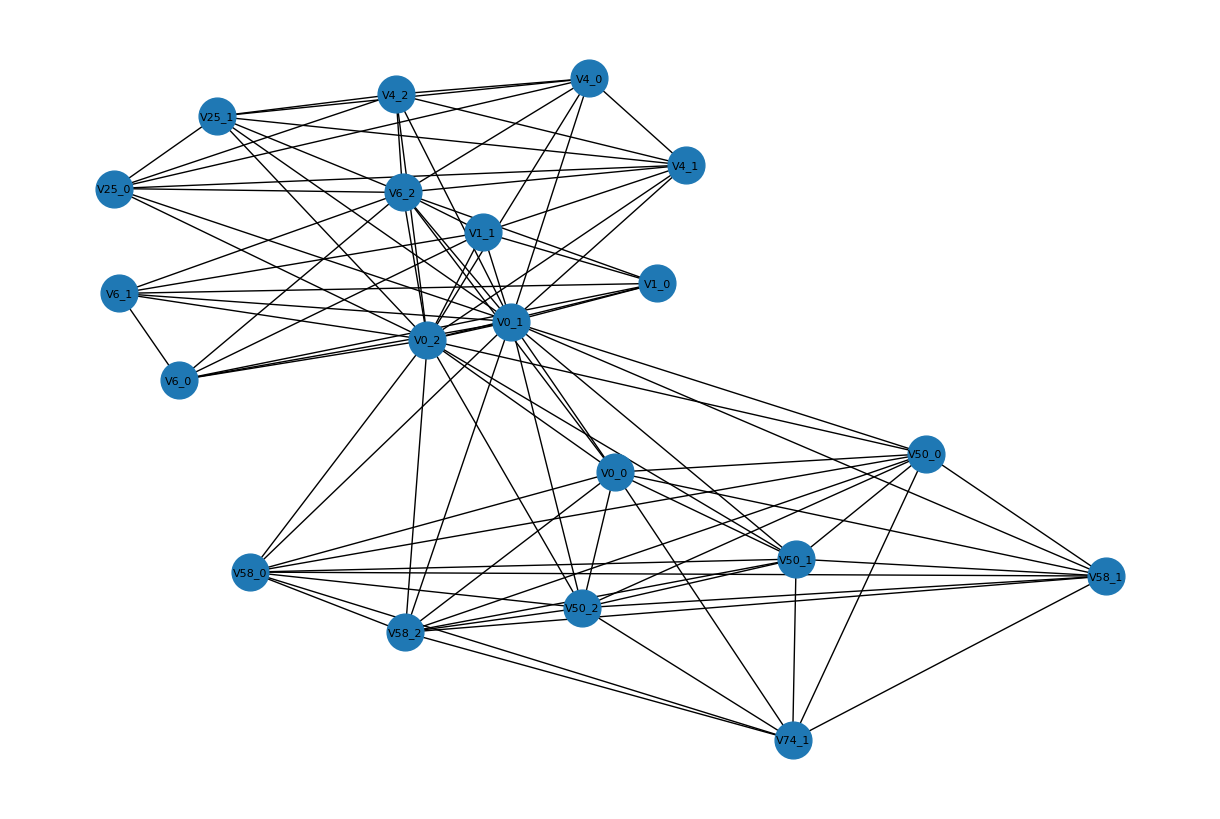

In [73]:
import networkx as nx
import matplotlib.pyplot as plt
sub_nodos = list(G.nodes())[:20]

subgrafo = G.subgraph(sub_nodos)

plt.figure(figsize=(12,8))

pos = nx.spring_layout(subgrafo, seed=42)

nx.draw(
    subgrafo,
    pos,
    with_labels=True,
    node_size=700,
    font_size=8
)

plt.show()

In [103]:
def buscar_hospital_adecuado(grafo, emergencia, hospitales, capacidades):

    especialidad = emergencia["especialidad_requerida"]
    nodo_origen = emergencia["id_nodo_origen"]

    # Copiar hospitales candidtos que tengan la capacidad correcta
    candidatos = capacidades[
        capacidades["especialidad"] == especialidad
    ].copy()

    # Calcula camas disponibles
    candidatos["camas_disponibles"] = (
        candidatos["camas_totales"] - candidatos["camas_ocupadas"]
    )

    # Quitamos hospitales sin camas disponibles
    candidatos = candidatos[candidatos["camas_disponibles"] > 0]

    if candidatos.empty:
        return None

    # Dijkstra desde el lugar de la emergencia
    padre, distancias = grafo.Dijkstra_costo(nodo_origen)

    mejor_hospital = None
    mejor_distancia = float("inf")

    # Buscar el hospital candidato más cercano según Dijkstra
    for i, candidato in candidatos.iterrows():

        id_hospital = candidato["id_hospital"]

        if id_hospital in distancias and distancias[id_hospital] < mejor_distancia:
            mejor_distancia = distancias[id_hospital]
            mejor_hospital = candidato

    if mejor_hospital is None:
        return None

    return {
        "id_hospital": mejor_hospital["id_hospital"],
        "hospital": mejor_hospital["hospital"],
        "especialidad": especialidad,
        "camas_disponibles": mejor_hospital["camas_disponibles"],
        "costo_ruta": mejor_distancia
    }

In [105]:
hospitales = pd.read_csv("hospitales_limpio.csv")
capacidades = pd.read_csv("capacidades.csv")
emergencias = pd.read_csv("emergencias.csv")

emergencia = emergencias.iloc[0]

resultado = buscar_hospital_adecuado(
    grafo,
    emergencia,
    hospitales,
    capacidades
)
resultado

{'id_hospital': 'node/319436637',
 'hospital': 'Hospital San Angel Inn',
 'especialidad': 'urgencias',
 'camas_disponibles': 9,
 'costo_ruta': 7.238}

In [53]:
print(resultado)

{'id_hospital': 'node/319436637', 'hospital': 'Hospital San Angel Inn', 'especialidad': 'urgencias', 'camas_disponibles': 3, 'costo_ruta': 7.238}


In [58]:
print(emergencia)

id_emergencia                         E01
id_nodo_origen                       V8_0
nombre_origen             Avenida Jalisco
lat                              19.39743
lon                            -99.190014
especialidad_requerida          urgencias
prioridad                            ROJO
Name: 0, dtype: object


In [60]:
capacidades[
    capacidades["especialidad"] == emergencia["especialidad_requerida"]
]

,id_hospital,hospital,especialidad,camas_totales,camas_ocupadas
2,relation/11632168,Complejo de hospitales IMSS,urgencias,1,4
16,node/319436637,Hospital San Angel Inn,urgencias,4,1
21,node/739035810,Clínica Hospital 8 IMSS,urgencias,13,5
28,way/986068924,Centro de Atención a la Salud T-III Jalalpa,urgencias,8,9
35,way/1365216619,"Hospital Regional ""Lic. Adolfo López Mateos""",urgencias,1,7
43,node/2324519237,Hospital General Enrique Cabrera,urgencias,13,8
50,node/4403446355,Hospital vicentino y casa hogar,urgencias,3,7


In [62]:
capacidades["camas_disponibles"] = (
    capacidades["camas_totales"]
    - capacidades["camas_ocupadas"]
)

capacidades[
    (capacidades["especialidad"] == emergencia["especialidad_requerida"])
    &
    (capacidades["camas_disponibles"] > 0)
]

,id_hospital,hospital,especialidad,camas_totales,camas_ocupadas,camas_disponibles
16,node/319436637,Hospital San Angel Inn,urgencias,4,1,3
21,node/739035810,Clínica Hospital 8 IMSS,urgencias,13,5,8
43,node/2324519237,Hospital General Enrique Cabrera,urgencias,13,8,5


In [64]:
padre, distancias = grafo.Dijkstra_costo(emergencia["id_nodo_origen"])

for id_hospital in capacidades[
    capacidades["especialidad"] == emergencia["especialidad_requerida"]
]["id_hospital"]:
    print(id_hospital, distancias.get(id_hospital, "NO LLEGA"))

relation/11632168 7.537
node/319436637 7.238
node/739035810 7.518
way/986068924 inf
way/1365216619 5.819
node/2324519237 7.706999999999999
node/4403446355 7.346


In [66]:
emergencia["id_nodo_origen"] in grafo.getOrigen()

True

In [68]:
for h in capacidades["id_hospital"].unique()[:10]:
    print(h, h in grafo.getOrigen())

relation/11632168 True
way/27804337 True
node/319436637 True
node/739035810 True
way/883666969 True
way/986068924 True
way/1364990384 True
way/1365216619 True
way/1365266055 True
node/2324519237 True


In [70]:
emergencia = emergencias.iloc[0]

padre, distancias = grafo.Dijkstra_costo(emergencia["id_nodo_origen"])

candidatos = capacidades[
    capacidades["especialidad"] == emergencia["especialidad_requerida"]
].copy()

candidatos["camas_disponibles"] = (
    candidatos["camas_totales"] - candidatos["camas_ocupadas"]
)

candidatos = candidatos[candidatos["camas_disponibles"] > 0]

for _, candidato in candidatos.iterrows():
    id_hospital = candidato["id_hospital"]
    print(
        id_hospital,
        candidato["hospital"],
        distancias.get(id_hospital, "NO EXISTE EN DISTANCIAS")
    )

node/319436637 Hospital San Angel Inn 7.238
node/739035810 Clínica Hospital 8 IMSS 7.518
node/2324519237 Hospital General Enrique Cabrera 7.706999999999999


In [75]:
#segunda parte: para el prim 
import pandas as pd

hospitales = pd.read_csv("hospitales_limpio.csv")

grafo_hospitales = Grafo()

for i, hospital1 in hospitales.iterrows():

    distancias = []

    for j, hospital2 in hospitales.iterrows():

        if hospital1["id_osm"] != hospital2["id_osm"]:

            d = distancia_km(
                hospital1["lat"],
                hospital1["lon"],
                hospital2["lat"],
                hospital2["lon"]
            )

            distancias.append((hospital2["id_osm"], d))

    # conectar con los 3 hospitales más cercanos
    cercanos = sorted(distancias, key=lambda x: x[1])[:3]

    for id_destino, d in cercanos:

        peso = {
            "distancia": round(d, 3),
            "trafico": 1.0,
            "costo": round(d, 3)
        }

        grafo_hospitales.inserta_no_dirigido(
            hospital1["id_osm"],
            id_destino,
            peso
        )

print("Grafo hospitalario generado")

Grafo hospitalario generado


In [77]:
#parto desde el primer hospital del dataframe
inicio = hospitales.iloc[0]["id_osm"]

#uso la funcion prim para que me devuelva
#padre: diccionario de los hospitales conectados
padre, llave = grafo_hospitales.prim_costo(inicio)

print("Padres del MST:")
print(padre)

print("\nCostos:")
print(llave)

Padres del MST:
{'relation/11632168': None, 'node/739035810': 'relation/11632168', 'node/4403446355': 'relation/11632168', 'node/319436637': 'node/4403446355', 'way/27804337': 'way/883666969', 'way/883666969': 'way/1364990384', 'node/2324519237': 'node/9768668045', 'node/9768668045': 'node/319436637', 'way/1364990384': 'node/319436637', 'way/1365266055': 'way/1364990384', 'way/986068924': 'node/2324519237', 'way/1365216619': 'way/1365266055', 'node/3977351148': 'way/986068924'}

Costos:
{'relation/11632168': 0, 'node/739035810': 0.077, 'node/4403446355': 0.321, 'node/319436637': 0.075, 'way/27804337': 1.213, 'way/883666969': 4.218, 'node/2324519237': 0.025, 'node/9768668045': 3.463, 'way/1364990384': 3.306, 'way/1365266055': 0.409, 'way/986068924': 1.897, 'way/1365216619': 0.058, 'node/3977351148': 5.914}


In [79]:
costo_total = sum(
    valor for valor in llave.values()
    if valor != np.inf
)

print("Costo total del MST:", round(costo_total, 3))

Costo total del MST: 20.976


In [111]:
import networkx as nx
import matplotlib.pyplot as plt

# Crear grafo visual solo con hospitales
G_hospitales = nx.Graph()

# Diccionario para ubicar nodos con coordenadas reales
noddles = {}

for _, row in hospitales.iterrows():
    id_hospital = row["id_osm"]
    nombre = row["nombre"]

    G_hospitales.add_node(id_hospital, label=nombre)
    noddles[id_hospital] = (row["lon"], row["lat"])

# Agregamos todas las conexiones del grafo hospitalario
for origen in grafo_hospitales.getOrigen():

    for destino, peso in grafo_hospitales.getOrigen()[origen].items():

        G_hospitales.add_edge(
            origen,
            destino,
            weight=round(peso["costo"], 2)
        )

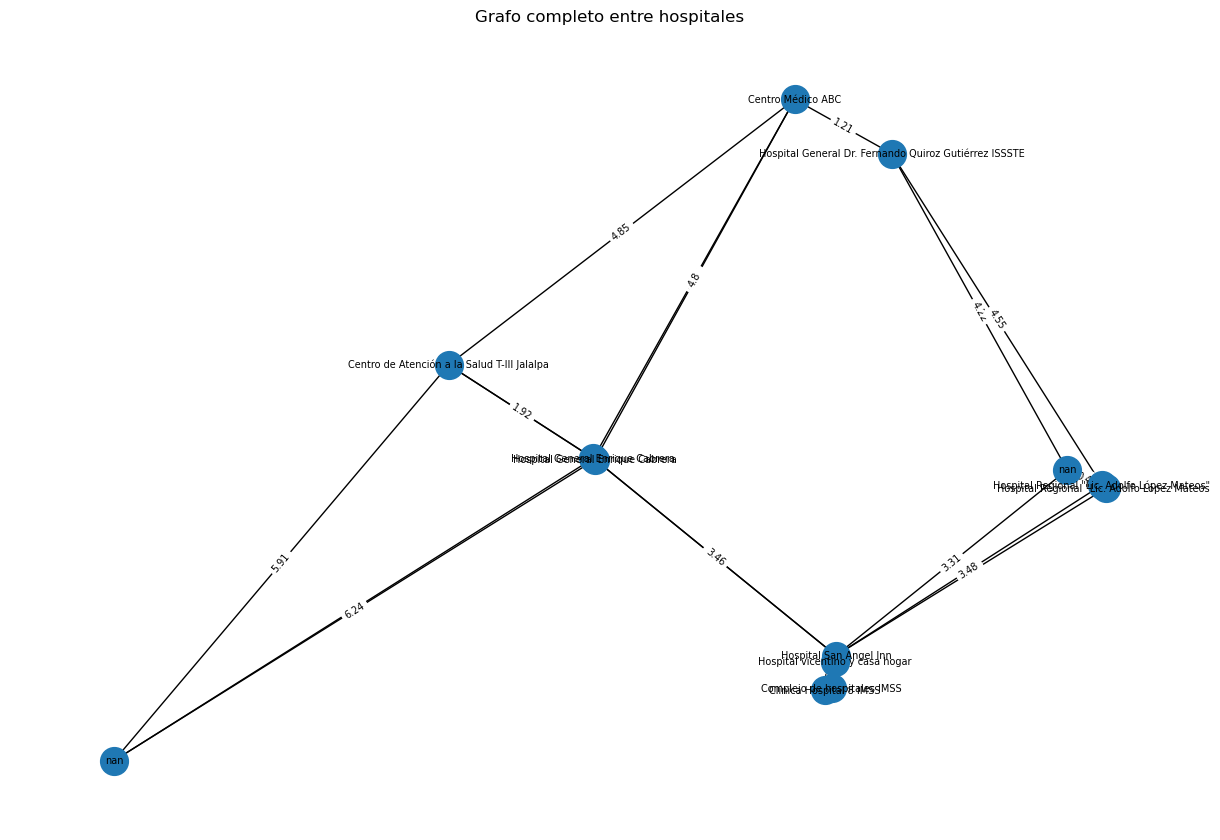

In [115]:
plt.figure(figsize=(12, 8))

nx.draw(
    G_hospitales,
    noddles,
    with_labels=False,
    node_size=400
)

labels = nx.get_node_attributes(G_hospitales, "label")

nx.draw_networkx_labels(
    G_hospitales,
    noddles,
    labels=labels,
    font_size=7
)

edge_labels = nx.get_edge_attributes(G_hospitales, "weight")

nx.draw_networkx_edge_labels(
    G_hospitales,
    noddles,
    edge_labels=edge_labels,
    font_size=7
)

plt.title("Grafo completo entre hospitales")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()

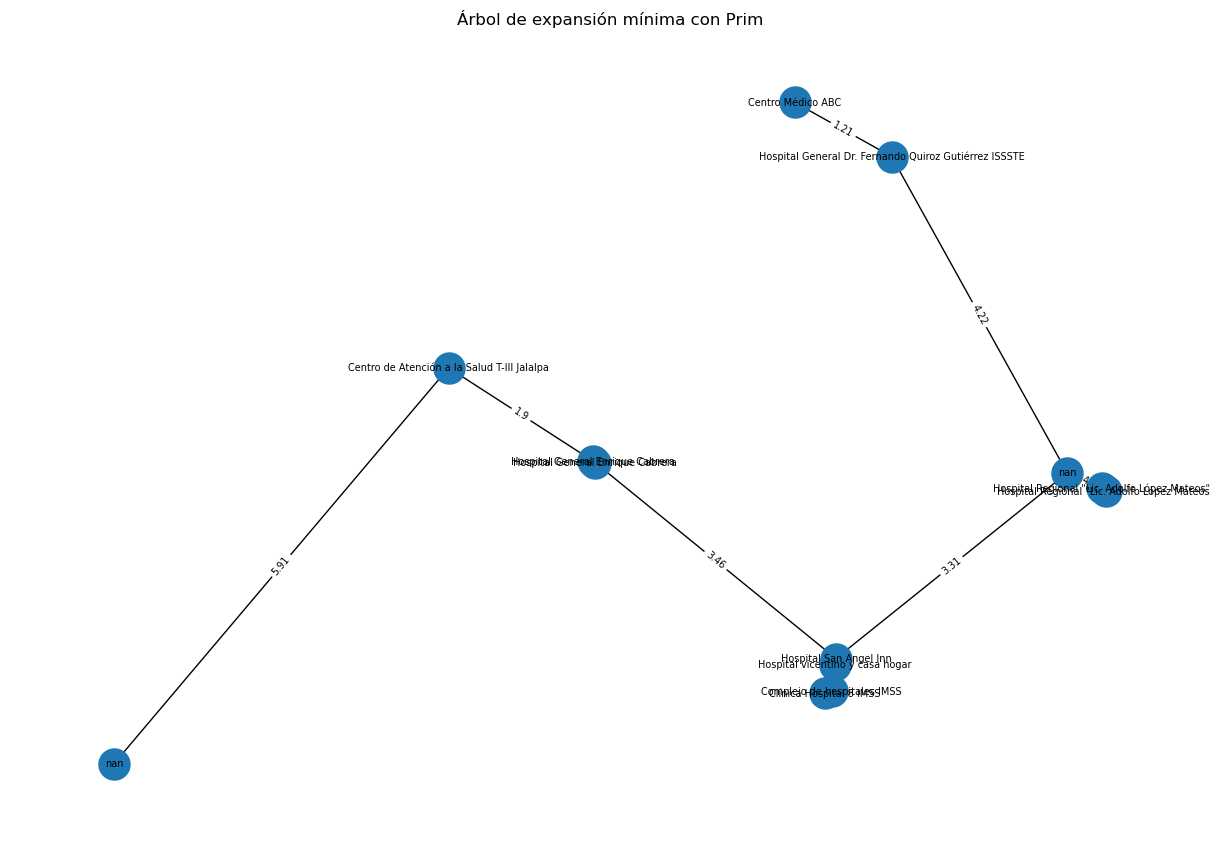

In [117]:
G_mst = nx.Graph()

for hijo, papa in padre.items():

    if papa is not None:

        costo = llave[hijo]

        G_mst.add_edge(
            papa,
            hijo,
            weight=round(costo, 2)
        )

plt.figure(figsize=(12, 8))

nx.draw(
    G_mst,
    noddles,
    with_labels=False,
    node_size=500
)

labels = nx.get_node_attributes(G_hospitales, "label")

nx.draw_networkx_labels(
    G_mst,
    noddles,
    labels=labels,
    font_size=7
)

edge_labels = nx.get_edge_attributes(G_mst, "weight")

nx.draw_networkx_edge_labels(
    G_mst,
    noddles,
    edge_labels=edge_labels,
    font_size=7
)

plt.title("Árbol de expansión mínima con Prim")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.show()